## TASK 5 · Sales Prediction Using Python

 **Objective**: Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, r2_score,root_mean_squared_error, mean_squared_error, mean_absolute_error

In [3]:
data= pd.read_csv('advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


#### Data Info

In [4]:
data.shape

(200, 4)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

**Observation**: In This Datasets , There Is No Duplicate Or Null Values Are Present.

In [9]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

## EDA

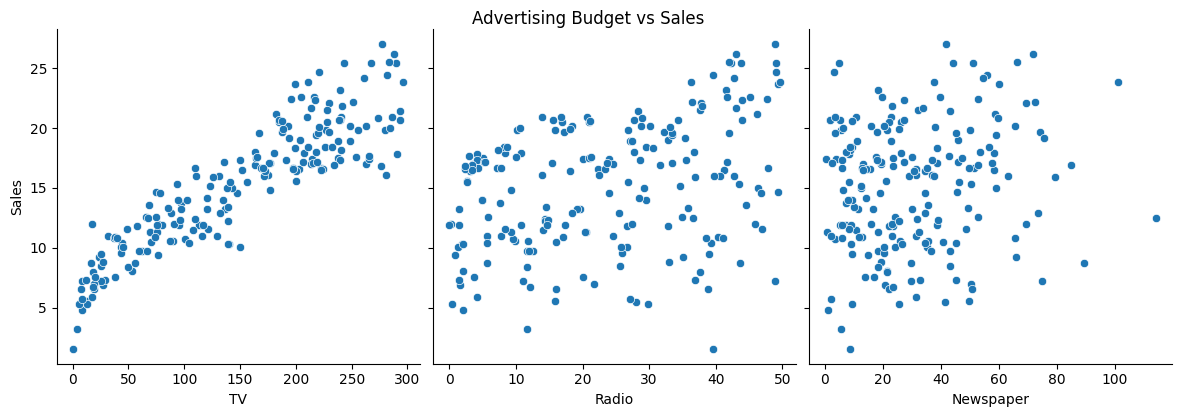

In [10]:
sns.pairplot(
    data[['TV','Radio','Newspaper','Sales']],
    x_vars=['TV','Radio','Newspaper'],
    y_vars='Sales',
    height=4
)

plt.suptitle("Advertising Budget vs Sales ",y=1.02)
plt.show()

The pairplot shows the relationship between advertising expenditure and sales. TV advertising has the strongest positive relationship with sales, followed by Radio advertising, while Newspaper advertising shows a weaker relationship.

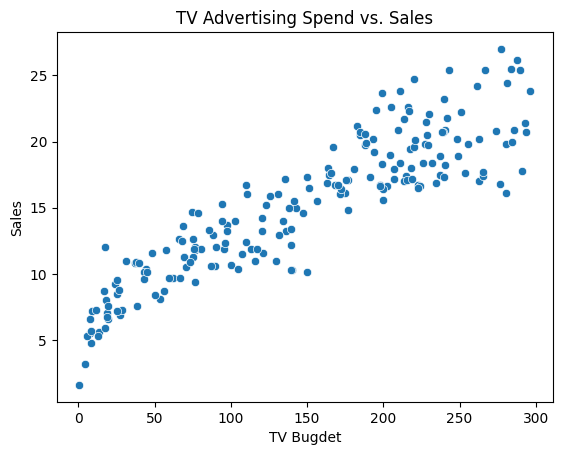

In [11]:
sns.scatterplot(x='TV',y='Sales', data=data)
plt.title("TV Advertising Spend vs. Sales")
plt.xlabel("TV Bugdet")
plt.ylabel('Sales')

plt.show()

Sales increase noticeably as TV advertising expenditure increases, indicating a strong positive linear relationship.

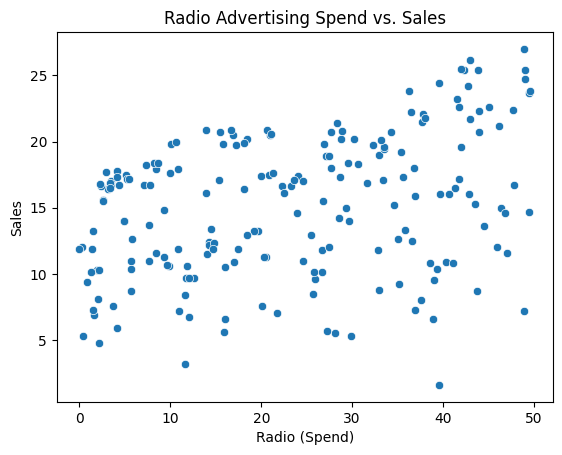

In [12]:
sns.scatterplot(x='Radio',y='Sales', data=data)
plt.title("Radio Advertising Spend vs. Sales")
plt.xlabel("Radio (Spend)")
plt.ylabel('Sales')

plt.show()

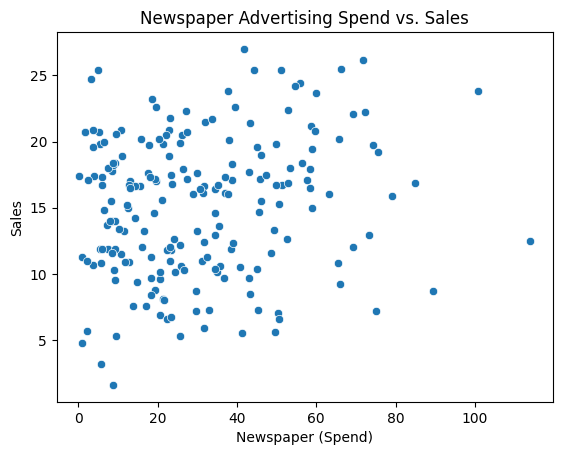

In [13]:
sns.scatterplot(x='Newspaper',y='Sales', data=data)
plt.title("Newspaper Advertising Spend vs. Sales")
plt.xlabel("Newspaper (Spend)")
plt.ylabel('Sales')

plt.show()

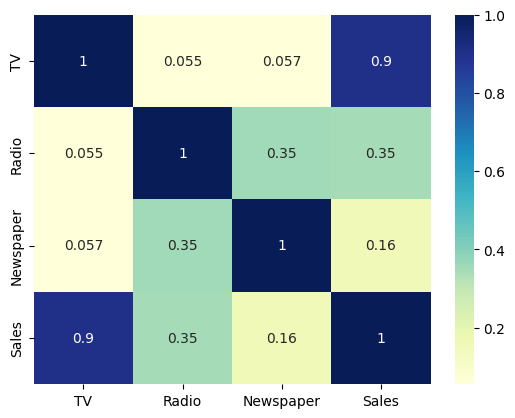

In [14]:
sns.heatmap(data.corr(),annot=True,cmap='YlGnBu')
plt.show()

### Observation

The correlation heatmap shows that **TV advertising has the strongest positive correlation with Sales (0.90)**, indicating that higher TV advertising expenditure is strongly associated with higher sales. **Radio advertising has a moderate positive correlation with Sales (0.35)**, while **Newspaper advertising has a weak positive correlation with Sales (0.16)**. The low correlation between TV and Radio (0.055) suggests that these advertising channels are largely independent of each other. Overall, TV advertising appears to be the most influential factor affecting sales in this dataset.

## Train/Test Split

In [15]:
X=data[['TV','Radio','Newspaper']]
y=data[['Sales']]

X_train, X_test, y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [16]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_Test:",y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160, 1)
y_Test: (40, 1)


#### Train the model

In [17]:
model= LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
prediction = model.predict(X_test)
prediction.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

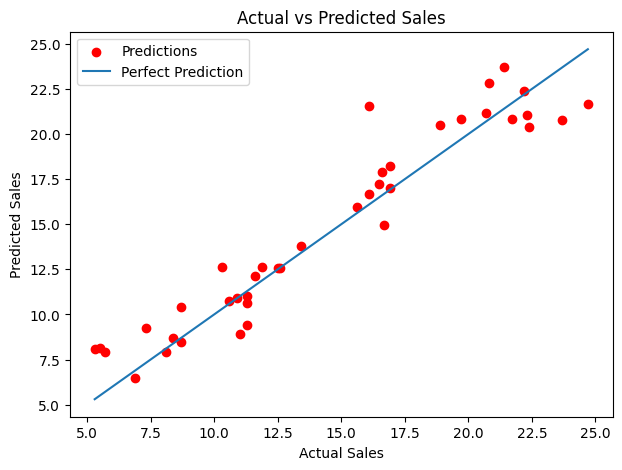

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, prediction, label='Predictions',color='red')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label='Perfect Prediction'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.legend()
plt.show()

In [ ]:
mae= mean_absolute_error(y_test,prediction)
rmse = np.sqrt(mean_squared_error(y_test,prediction))
r2= r2_score(y_test,prediction)
print("MAE:",mae)
print("RMAE:",rmse)
print("R2 Score:",r2)

MAE: 1.2748262109549338
RMAE: 1.7052146229349223
R2 Score: 0.9059011844150826


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
R_model = RandomForestRegressor(n_estimators=100,random_state=42)
R_model.fit(X_train,y_train)

c:\Users\bipin\OneDrive\Desktop\python\pandas\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
R_predict=R_model.predict(X_test)
R_predict

array([17.299, 22.482, 19.77 ,  6.784, 22.961, 13.471, 22.595,  9.579,
       16.887, 16.793,  7.499, 10.327, 17.345,  5.132, 11.5  , 16.902,
        6.549, 17.788, 11.666, 19.766, 19.965, 13.134, 10.018, 21.83 ,
       10.854, 10.04 , 22.645, 12.476, 11.495,  5.301, 16.558, 11.231,
       22.945, 10.405, 19.736, 20.114, 10.977, 19.547, 12.437,  7.395])

In [ ]:
rf_mae= mean_absolute_error(y_test,R_predict)
rf_rmse = np.sqrt(mean_squared_error(y_test,R_predict))
rf_r2= r2_score(y_test,R_predict)
print("MAE:",rf_mae)
print("RMAE:",rf_rmse)
print("R2 Score:",rf_r2*100)

MAE: 0.9179999999999993
RMAE: 1.1989298770153327
R2 Score: 95.34827934927883


In [ ]:
comparision= pd.DataFrame({
    "Model":['LinearRegression','RandomForestRegressor'],
    "MAE":[mae,rf_mae],
    "RMSE":[rmse,rf_rmse],
    "R2":[r2,rf_r2],
})
comparision

,Model,MAE,RMSE,R2
0,LinearRegression,0.918,1.19893,0.953483
1,RandomForestRegressor,0.918,1.19893,0.953483


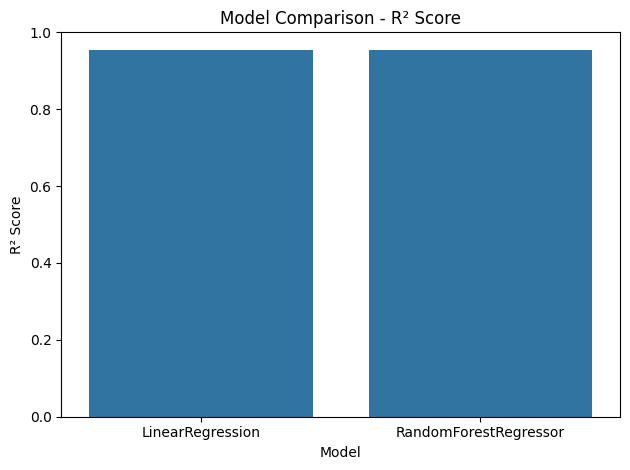

In [ ]:
sns.barplot(
    x=comparision['Model'],
    y=comparision['R2']
)
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

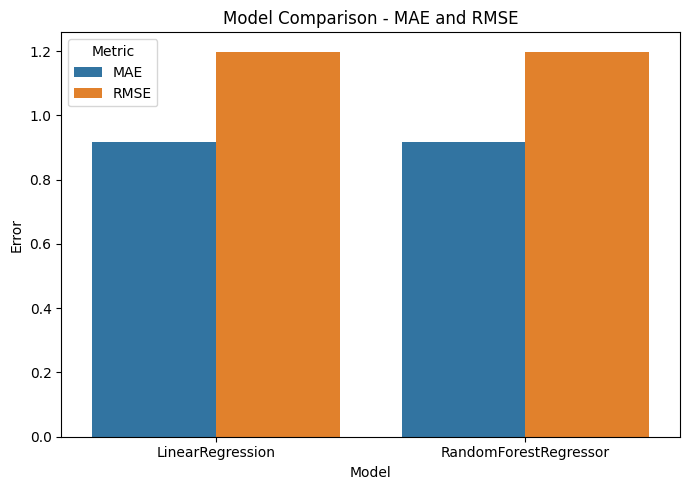

In [ ]:
comparison_errors = comparision.melt(
    id_vars='Model',
    value_vars=['MAE', 'RMSE'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='Value',
    hue='Metric',
    data=comparison_errors
)

plt.title("Model Comparison - MAE and RMSE")
plt.ylabel("Error")
plt.xlabel("Model")

plt.tight_layout()
plt.show()